In [19]:
# Libraries

import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

First we should call datasets from splitting section.


In [5]:
%store -r X_train
X_train = X_train

%store -r y_train
y_train = y_train

%store -r X_val
X_val = X_val

%store -r y_val
y_val = y_val

%store -r X_test
X_test = X_test

%store -r y_test
y_test = y_test


In the next section, based on each model, we define specific pipeline and buildnand train model

In [8]:
def evaluate_model(X_train, y_train, X_val, y_val, model):
    # K-Fold Cross Validation
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    # Cross Validation Scores
    cross_val_r2 = cross_val_score(
        model,
        X_train,
        y_train,
        cv=kf,
        scoring='r2'
    )

    cross_val_rmse = cross_val_score(
        model,
        X_train,
        y_train,
        cv=kf,
        scoring='neg_root_mean_squared_error'
    )

    print(f"Training CV R²: {cross_val_r2.mean():.4f}")
    print(f"Training CV RMSE: {abs(cross_val_rmse.mean()):.4f}")

    # Train Model
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    # Training Metrics
    r2_train = r2_score(y_train, y_train_pred)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))

    # Validation Metrics
    r2_val = r2_score(y_val, y_val_pred)
    rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))

    # Print Results
    print(f"Training R²: {r2_train:.4f}")
    print(f"Training RMSE: {rmse_train:.4f}")

    print(f"Validation R²: {r2_val:.4f}")
    print(f"Validation RMSE: {rmse_val:.4f}")

MODEL TRAINING


In [9]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("lin_reg", LinearRegression())
])

evaluate_model(X_train, y_train, X_val, y_val, model)

Training CV R²: 0.9991
Training CV RMSE: 95.2011
Training R²: 0.9991
Training RMSE: 95.8568
Validation R²: 0.9996
Validation RMSE: 63.3000


The model is not underfit (both CV and validation are high) and overfit(CV and validationa are close to each other)

In [ ]:
DECISION TREE REGRESSOR

In [10]:
model = Pipeline([
    ("DecisionTree_reg", DecisionTreeRegressor())
])

evaluate_model(X_train, y_train, X_val, y_val, model)

Training CV R²: 0.8923
Training CV RMSE: 1027.8550
Training R²: 1.0000
Training RMSE: 0.0000
Validation R²: 0.8985
Validation RMSE: 990.3362


The model is not underfit (both CV train and train have gap).But, since the gap between CV train and validationa are small,that overfitting is not severe.

RANDOMFOREST REGRESSOR

In [11]:
model = Pipeline([
    ("RandomForest_reg", RandomForestRegressor())
])

evaluate_model(X_train, y_train, X_val, y_val, model)

Training CV R²: 0.9597
Training CV RMSE: 627.6312
Training R²: 0.9950
Training RMSE: 221.7829
Validation R²: 0.9630
Validation RMSE: 598.0593


The model is not underfit(both cv and validation are high) and overfit(cv and validation are close to each other).

SUPPORT VECTOR MACHINE

In [9]:
model = Pipeline([
    ("SVR_reg", SVR())
])

evaluate_model(X_train, y_train, X_val, y_val, model)

Training CV R²: 0.1333
Training CV RMSE: 2919.9628
Training R²: 0.1547
Training RMSE: 2884.8119
Validation R²: 0.1502
Validation RMSE: 2864.8880


The model is not underfitting because both training and cross-validation scores are reasonably good. There is a slight gap between training and validation performance, indicating minor overfitting, but the difference is small and acceptable. Therefore, the model generalizes reasonably well on unseen data.

XGBOOST REGRESSOR

In [12]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("xgb", XGBRegressor(objective='reg:squarederror'))
])

evaluate_model(X_train, y_train, X_val, y_val, model)

Training CV R²: 0.9920
Training CV RMSE: 280.2197
Training R²: 0.9986
Training RMSE: 116.9903
Validation R²: 0.9928
Validation RMSE: 264.4133


The model is not underfit(both cv and validation are high)and overfit (cv and validation are close to each other)

CATBOOST REGRESSION

In [18]:
model = Pipeline([
    ("catboost", CatBoostRegressor())
])

evaluate_model(X_train, y_train, X_val, y_val, model)

Learning rate set to 0.052996
0:	learn: 3002.5386655	total: 144ms	remaining: 2m 23s
1:	learn: 2890.4135878	total: 148ms	remaining: 1m 13s
2:	learn: 2774.6653173	total: 152ms	remaining: 50.4s
3:	learn: 2665.5842386	total: 155ms	remaining: 38.5s
4:	learn: 2567.5958915	total: 158ms	remaining: 31.4s
5:	learn: 2469.5098712	total: 160ms	remaining: 26.6s
6:	learn: 2376.9738903	total: 163ms	remaining: 23.1s
7:	learn: 2297.0043203	total: 166ms	remaining: 20.5s
8:	learn: 2215.1927629	total: 167ms	remaining: 18.4s
9:	learn: 2139.8163751	total: 169ms	remaining: 16.7s
10:	learn: 2063.5877621	total: 171ms	remaining: 15.4s
11:	learn: 1992.1604502	total: 173ms	remaining: 14.3s
12:	learn: 1923.5305228	total: 175ms	remaining: 13.3s
13:	learn: 1858.1751387	total: 177ms	remaining: 12.5s
14:	learn: 1799.7401392	total: 179ms	remaining: 11.7s
15:	learn: 1743.3864607	total: 180ms	remaining: 11.1s
16:	learn: 1686.5267358	total: 182ms	remaining: 10.5s
17:	learn: 1628.8700788	total: 184ms	remaining: 10.1s
18:	le

The model is not underfit(both cv and validation are high) and (Cv and validation are close to each other)

In [ ]:
ADABOOST REGRESSION

In [20]:
model = Pipeline([
    ("adaboost", AdaBoostRegressor())
])

evaluate_model(X_train, y_train, X_val, y_val, model)

Training CV R²: 0.8851
Training CV RMSE: 1064.4164
Training R²: 0.8913
Training RMSE: 1034.4144
Validation R²: 0.8845
Validation RMSE: 1056.2498


MODEL SELECTION

In [21]:
# Best Model
best_model = CatBoostRegressor()
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Cross Validation Metrics
cross_val_r2 = cross_val_score(
    best_model,
    X_train,
    y_train,
    cv=kf,
    scoring='r2'
)

cross_val_rmse = -cross_val_score(
    best_model,
    X_train,
    y_train,
    cv=kf,
    scoring='neg_root_mean_squared_error'
)

# Print CV Results
print(f"Training CV R²: {cross_val_r2.mean():.4f}")
print(f"Training CV RMSE: {cross_val_rmse.mean():.4f}")

# Train the Model
best_model.fit(X_train, y_train)

# Predictions
y_train_pred = best_model.predict(X_train)
y_val_pred = best_model.predict(X_val)

# Training Metrics
r2_train = r2_score(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))

# Validation Metrics
r2_val = r2_score(y_val, y_val_pred)
rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))

# Print Final Results
print(f"Training R²: {r2_train:.4f}")
print(f"Training RMSE: {rmse_train:.4f}")

print(f"Validation R²: {r2_val:.4f}")
print(f"Validation RMSE: {rmse_val:.4f}")

Learning rate set to 0.052996
0:	learn: 3002.5386655	total: 3.26ms	remaining: 3.26s
1:	learn: 2890.4135878	total: 5.24ms	remaining: 2.62s
2:	learn: 2774.6653173	total: 6.85ms	remaining: 2.28s
3:	learn: 2665.5842386	total: 8.52ms	remaining: 2.12s
4:	learn: 2567.5958915	total: 10.2ms	remaining: 2.04s
5:	learn: 2469.5098712	total: 11.9ms	remaining: 1.97s
6:	learn: 2376.9738903	total: 14.9ms	remaining: 2.12s
7:	learn: 2297.0043203	total: 17.4ms	remaining: 2.16s
8:	learn: 2215.1927629	total: 19.5ms	remaining: 2.14s
9:	learn: 2139.8163751	total: 21.4ms	remaining: 2.12s
10:	learn: 2063.5877621	total: 24.1ms	remaining: 2.17s
11:	learn: 1992.1604502	total: 25.7ms	remaining: 2.12s
12:	learn: 1923.5305228	total: 27.7ms	remaining: 2.1s
13:	learn: 1858.1751387	total: 30.3ms	remaining: 2.14s
14:	learn: 1799.7401392	total: 32.2ms	remaining: 2.12s
15:	learn: 1743.3864607	total: 33.9ms	remaining: 2.08s
16:	learn: 1686.5267358	total: 35.6ms	remaining: 2.06s
17:	learn: 1628.8700788	total: 37.2ms	remainin

TUNE MODEL WITH HYPER PARAMTER

Now in this section, we try to tune model and improve is performance

In [23]:
param_grid = {
    'iterations': [100, 200],              # Number of boosting iterations
    'learning_rate': [0.01, 0.05, 0.1],   # Step size at each iteration
    'depth': [4, 6, 8],                   # Depth of the trees
    'l2_leaf_reg': [1, 3, 5],             # L2 regularization coefficient
    'border_count': [32, 64]              # Number of splits for features
}

# Grid Search
grid_search = GridSearchCV(
    estimator=best_model,
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=2
)

# Train Grid Search
grid_search.fit(X_train, y_train)

# Best Parameters
print("Best parameters found:", grid_search.best_params_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
0:	learn: 2891.2346180	total: 11.7ms	remaining: 2.33s
1:	learn: 2668.8933077	total: 21.8ms	remaining: 2.16s
2:	learn: 2459.9756447	total: 32.2ms	remaining: 2.12s
3:	learn: 2268.0262502	total: 41.5ms	remaining: 2.03s
4:	learn: 2101.5786230	total: 47.9ms	remaining: 1.87s
5:	learn: 1943.3093160	total: 55.9ms	remaining: 1.81s
6:	learn: 1792.1020532	total: 61.9ms	remaining: 1.71s
7:	learn: 1653.1111994	total: 67.7ms	remaining: 1.62s
8:	learn: 1527.1311250	total: 74ms	remaining: 1.57s
9:	learn: 1428.5181867	total: 79.6ms	remaining: 1.51s
10:	learn: 1325.7906953	total: 86.4ms	remaining: 1.48s
11:	learn: 1225.5528466	total: 91.8ms	remaining: 1.44s
12:	learn: 1145.1798397	total: 97.4ms	remaining: 1.4s
13:	learn: 1070.7260044	total: 103ms	remaining: 1.37s
14:	learn: 998.3574971	total: 109ms	remaining: 1.34s
15:	learn: 936.2662415	total: 116ms	remaining: 1.34s
16:	learn: 872.7640039	total: 123ms	remaining: 1.32s
17:	learn: 823.0052708

In [25]:
best_model_tuned = grid_search.best_estimator_

In [26]:
# Best Tuned Model
best_model_tuned = grid_search.best_estimator_

# K-Fold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Cross Validation Scores
cross_val_r2 = cross_val_score(
    best_model_tuned,
    X_train,
    y_train,
    cv=kf,
    scoring='r2'
)

cross_val_rmse = -cross_val_score(
    best_model_tuned,
    X_train,
    y_train,
    cv=kf,
    scoring='neg_root_mean_squared_error'
)

# Print CV Results
print(f"Training CV R²: {cross_val_r2.mean():.4f}")
print(f"Training CV RMSE: {cross_val_rmse.mean():.4f}")

# Train Tuned Model
best_model_tuned.fit(X_train, y_train)

# Predictions
y_train_pred = best_model_tuned.predict(X_train)
y_val_pred = best_model_tuned.predict(X_val)

# Training Metrics
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
r2_train = r2_score(y_train, y_train_pred)

# Validation Metrics
r2_val = r2_score(y_val, y_val_pred)
rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))

# Print Final Results
print(f"Training R²: {r2_train:.4f}")
print(f"Training RMSE: {rmse_train:.4f}")

print(f"Validation R²: {r2_val:.4f}")
print(f"Validation RMSE: {rmse_val:.4f}")

0:	learn: 2888.9038597	total: 2.74ms	remaining: 545ms
1:	learn: 2666.6848766	total: 5.4ms	remaining: 534ms
2:	learn: 2457.7945036	total: 7.85ms	remaining: 515ms
3:	learn: 2264.0649998	total: 11.7ms	remaining: 572ms
4:	learn: 2107.1511769	total: 14.5ms	remaining: 567ms
5:	learn: 1947.7858787	total: 16.6ms	remaining: 537ms
6:	learn: 1803.5933289	total: 18.6ms	remaining: 512ms
7:	learn: 1673.0132176	total: 20.9ms	remaining: 501ms
8:	learn: 1547.1883950	total: 22.9ms	remaining: 486ms
9:	learn: 1451.4864379	total: 25.9ms	remaining: 493ms
10:	learn: 1341.2997862	total: 28ms	remaining: 481ms
11:	learn: 1249.0347090	total: 29.7ms	remaining: 465ms
12:	learn: 1168.6492901	total: 31.3ms	remaining: 451ms
13:	learn: 1084.4820003	total: 33.1ms	remaining: 440ms
14:	learn: 1011.2906088	total: 35.1ms	remaining: 433ms
15:	learn: 937.0832152	total: 36.7ms	remaining: 422ms
16:	learn: 873.2688874	total: 39.7ms	remaining: 427ms
17:	learn: 818.7546156	total: 41.7ms	remaining: 422ms
18:	learn: 763.6390680	tot

since the tuned model is not better than default parameter, we consider default model as the final model

In [ ]:
final_model = best_model

FINAL EVALUATION MODEL

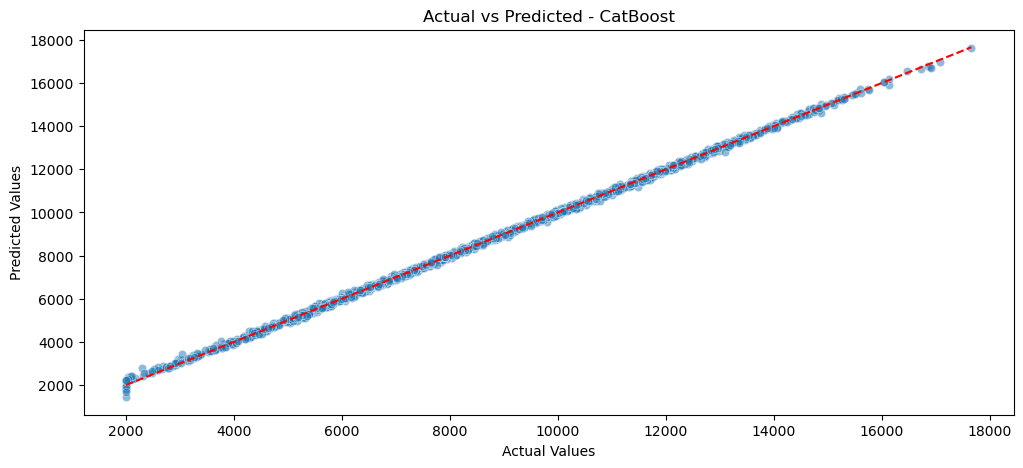

In [27]:
# Scatter Plot: Actual vs Predicted
plt.figure(figsize=(12, 5))

sns.scatterplot(
    x=y_val,
    y=y_val_pred,
    alpha=0.5
)

# Perfect Prediction Line
plt.plot(
    [min(y_val), max(y_val)],
    [min(y_val), max(y_val)],
    '--',
    color='red'
)

# Labels and Title
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted - CatBoost")
plt.show()

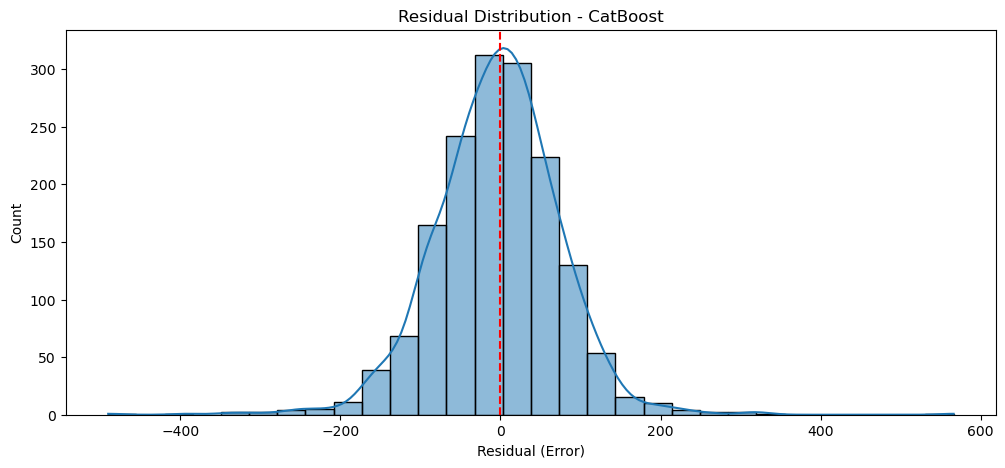

In [28]:
# Residual Plot (Errors)

# Calculate Residuals
residuals = y_val - y_val_pred

# Plot
plt.figure(figsize=(12, 5))

sns.histplot(
    residuals,
    bins=30,
    kde=True
)

# Reference Line at 0
plt.axvline(
    0,
    color='red',
    linestyle='dashed'
)

# Labels and Title
plt.xlabel("Residual (Error)")
plt.title("Residual Distribution - CatBoost")

# Show Plot
plt.show()

APPLY MODEL ON TEST DATA

 Here, that we are happy with model of the project ,we can predict the price on the test data.But before prediction we need to encode categorical preprocessing we did)

In [ ]:
with open('../../models/Brand_Encoder.pkl', 'rb') as f:
    brand_encoder = pickle.load(f) #Brand
with open('../../models/Model_Encoder.pkl', 'rb') as f:
    model_encoder = pickle.load(f) #model
with open('../../models/OneHot_Encoder.pkl', 'rb') as f:
    onehot_encoder = pickle.load(f) #Fuel, Transmission

FileNotFoundError: [Errno 2] No such file or directory: '../../models/OneHot_Encoder.pkl'